# What drives the price of a car?

**OVERVIEW**

In this assignment, I explore a provided dataset (derived from Kaggle) on used-cars. Using the CRISP-DM framework, the goal of this project is to understand what factors make a car more or less expensive and provide recommendations to a used-car dealership as to what consumers value in a used car.

### 1. Business Understanding

The client is a used-car dealership that wants to understand the car features that affect resale prices. 
- Business problem: Which car characteristics do consumers value most?
- Data science problem: Use observed car characteristics and market prices (customers' revealed preferences when purchasing) to assess which characteristics contribute most to differences in price and predict car prices.

The goal is to identify most influential features, quantify their relationship to price, and choose a preferred model (based on out-of-sample prediction performance) to make recommendations to dealership owner. 

### 2. Data Understanding

In [120]:
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv('/Users/ceci/Library/Mobile Documents/com~apple~CloudDocs/MLAI_Berkeley/Modules/Module 11 Practical Application 2/Deliverable/data/vehicles.csv')

In [122]:
df.dropna().head(3)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,"2,018.00",chevrolet,express cargo van,like new,6 cylinders,gas,"68,472.00",clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,"2,019.00",chevrolet,express cargo van,like new,6 cylinders,gas,"69,125.00",clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,"2,018.00",chevrolet,express cargo van,like new,6 cylinders,gas,"66,555.00",clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

#### 2.1 Missing data
- Key variables that are likely to be highly predictive of price — such as year of the car, odometer, manufacturer, fuel, title, and transmission — have relatively low missingness (0.3%–4.1%). Particularly high missingness for size (72%), cylinders (42%), condition (41%) and paint color (31%). 

In [124]:
df.describe()

# Missing data
missing = pd.DataFrame({
    'N_missing': df.isna().sum(),
    'Percent_missing': df.isna().mean() * 100
})

missing.sort_values('Percent_missing', ascending=False)

,N_missing,Percent_missing
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


#### 2.2. Outliers
- There are clear outliers in the price data: The maximum car price is 3.7 billion when 99% of cars cost less than about 67k. Also, at least 5% have a price of $0. 
- These high valued outliers explain why the mean (75K) is so much higher than the median price (14K).

In [125]:
pd.options.display.float_format = '{:,.2f}'.format
df['price'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count         426,880.00
mean           75,199.03
std        12,182,282.17
min                 0.00
1%                  0.00
5%                  0.00
25%             5,900.00
50%            13,950.00
75%            26,485.75
95%            44,500.00
99%            66,995.00
max     3,736,928,711.00
Name: price, dtype: float64

In [126]:
df['odometer'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count      422,480.00
mean        98,043.33
std        213,881.50
min              0.00
1%               2.00
5%           6,318.00
25%         37,704.00
50%         85,548.00
75%        133,542.50
95%        204,000.00
99%        280,000.00
max     10,000,000.00
Name: odometer, dtype: float64

#### 2.3. Duplicates

In [127]:
# Count duplicates based on ID, VIN, and year
print("Duplicate IDs:", df.duplicated(subset=['id']).sum())
print("Duplicate VINs:", df.duplicated(subset=['VIN']).sum())
print("Duplicate IDs VINs year:", df.duplicated(subset=['VIN','year','id']).sum())
print("Duplicate VINs year:", df.duplicated(subset=['VIN','year']).sum())

Duplicate IDs: 0
Duplicate VINs: 308633
Duplicate IDs VINs year: 0
Duplicate VINs year: 308394


#### 2.4 Explore other variables for unexpected values abnormalities (commented out from the output)

In [128]:
#df["year"].value_counts(dropna=False).sort_index()

In [129]:
#categorical_vars = ["title_status", "drive", "size","condition", "cylinders", "type", "transmission", "paint_color","fuel"]
#for var in categorical_vars:
#    print("\nPercent:")
#    print(df[var].value_counts(normalize=True, dropna=False).mul(100).round(1))

# Model has many unique values, show top 5
#print("\n--- model (Top 5) ---")
#print(df[["model" , "manufacturer"]]
#      .value_counts(normalize=True, dropna=False)
#      .head(5)
#      .mul(100)
#      .round(1))

#### 2.5. Relationship with Price (assessed as part of the EDA below) 

### 3. Data Preparation

Based on what I learned during the data exploration, I addressed several data quality issues before conducting the analysis:

- Missing values: Features such as odometer, manufacturer, and year are important for estimating vehicle prices. Observations with missing values for variables required in the analysis were therefore dropped.
- Duplicates: I removed duplicate observations with the same VIN, year, and price when VIN was available. Missing VINs were retained.
- Price and mileage restrictions: I removed vehicles that were likely new based on very low odometer readings, as well as vehicles with unusually high mileage. I also excluded vehicles priced below $2,000—including many observations with a price of zero, which may represent parts or invalid listings—and extremely high-priced vehicles that are more likely to be specialty cars.
- Title status: I restricted the analytic sample to vehicles with a clean title, which represented approximately 95% of the relevant sample. This excluded salvage, parts-only, rebuilt, lien, other, and missing title statuses.

- Manufacturer imputation: The model variable is a messy text field that sometimes contains the vehicle manufacturer. When manufacturer was missing, I used information contained in model to impute the manufacturer, recovering 329 observations from the full database (126 after sample restrictions). I used an iterative process in which I exported and manually reviewed the imputed cases to check their accuracy.

I used regular expressions (regex) to identify manufacturer names within model strings. Before matching, I converted model to lowercase and excluded unreliable model descriptions when:
    - they contained commas suggesting multiple manufacturers (e.g., "honda,toyota,nissan,chevy" or "chevy,ford, international"), or
    - they contained multiple hyphens suggesting multiple manufacturers (e.g., "ram-dodge-vw-toyota-honda-subaru" or "toyota-nissan-ford-chevy-dodge"). To be conservative, I imputed manufacturer names if exact word matches were found in the strings, with two exceptions: 
    - to accommodate common Mercedes-Benz/Benz variations and
    - to ensure that "ram" was matched only as a standalone word.

Ideas for future work: 
- Additional cleaning of the model variable would be valuable because it is relevant for price but it contains highly inconsistent free-text entries.
- Further cleaning of manufacturer could be possible. For example, I am not expert in cars, but I don't think "saturn" is a manufacturer, and "mercury" is a ford brand so pressumably could be grouped under the parent manufacturer.
- potentially important predictors such as condition were excluded because of substantial missingness (approximately 40%). Future work could explore retaining these variables using appropriate missing-data or imputation techniques rather than excluding them from the analysis.

#### 3.1. Sample Restrictions

In [130]:
# Preserve a copy before cleaning (removing outliers, duplicates, etc)
df_original = df.copy()

In [131]:
# Remove outliers on price and odometer
df = df[
    df["price"].between(2_000, 300000) &
    df["odometer"].between(500, 200000)
].copy()

print("Before:", len(df_original))
print("After:", len(df))
print("Removed:", len(df_original) - len(df))
print("Percent removed:",
      round((len(df_original) - len(df)) / len(df_original) * 100, 1), "%")

Before: 426880
After: 345516
Removed: 81364
Percent removed: 19.1 %


In [132]:
#Drop duplicates on VIN year and price
n_before = len(df)

# Identify duplicates only among observations with a non-missing VIN
duplicates = (
    df["VIN"].notna() &
    df.duplicated(
        subset=["VIN", "year", "price"],
        keep="first"
    )
)

# Drop those duplicates
df = df[~duplicates].copy()

print("Duplicates removed:", n_before - len(df))
print("Observations remaining:", len(df))

Duplicates removed: 124409
Observations remaining: 221107


In [133]:
#Keep title=clean 
n_before = len(df)

df = df[df["title_status"] == "clean"].copy()

print("Observations dropped:", n_before - len(df))
print("Observations remaining:", len(df))

Observations dropped: 13520
Observations remaining: 207587


In [134]:
#Keep 1990-2021 (very few obs for 2022 and lots of missing data) 
n_before = len(df)

df = df[
    df["year"].notna() &
    df["year"].between(1990, 2021)
].copy()

print("Observations dropped:", n_before - len(df))
print("Observations remaining:", len(df))

Observations dropped: 9494
Observations remaining: 198093


#### 3.2. Creating grouped variables and cleaning 

In [135]:
#convert year and odometer in integrer 
df["year"] = df["year"].astype("Int64")
df["odometer"] = df["odometer"].astype("Int64")

In [136]:
# group year into decades for graphing
df["decade"] = (df["year"] // 10) * 10

# group odometer in bins for graphing
bins = range(0, 210000, 10000)
labels = [f"{i//1000}-{(i+10000)//1000}k" for i in bins[:-1]]

df["odometer_bin"] = pd.cut(
    df["odometer"],
    bins=bins,
    labels=labels,
    right=False
)

#### 3.3. Impute manufacturer from model

In [137]:
manufacturers = (
    df["manufacturer"]
    .dropna()
    .str.lower()
    .str.strip()
    .unique()
)

# Start completely fresh
df["manufacturer_imputed"] = df["manufacturer"].copy()
df["manufacturer_from_model"] = pd.NA

# Make sure model is lowercase
df["model"] = df["model"].str.lower().str.strip()

#do not use model for imputation with multiple commas (for example, "honda,toyota,nissan,chevy", "chevy,ford, international")
df.loc[
    df["model"].str.contains(",", na=False),
    "model"
] = pd.NA

#do not use model for imputation when multiple hypthens (for example "ram-dodge-vw-toyota-honda-subaru", "toyota-nissan-ford-chevy-dodge"
df.loc[
    df["model"].str.count("-") > 1,
    "model"
] = pd.NA

#Use exact matches, except for mercedes-benz which also appears as benz. Force "ram" to have spaces in between to avoid classifying as ram things like "special program" or "rambler") 
def find_manufacturer(model):
    if pd.isna(model):
        return pd.NA

    # Mercedes-Benz:
    # allow "benz", "mercedes benz", "mercedes-benz", misspellings before benz, etc.
    if re.search(r"\bbenz\b", model):
        return "mercedes-benz"

    # RAM must be a standalone word
    # matches "ram 1500" but NOT "rambler"
    if re.search(r"\bram\b", model):
        return "ram"

    # Check all remaining manufacturers as whole words/phrases
    for manufacturer in manufacturers:

        if manufacturer in ["ram", "mercedes-benz"]:
            continue

        # Escape special regex characters
        pattern = r"\b" + re.escape(manufacturer) + r"\b"

        if re.search(pattern, model):
            return manufacturer

    return pd.NA


# Recreate manufacturer inferred from model
df["manufacturer_from_model"] = df["model"].apply(find_manufacturer)

# ONLY impute where original manufacturer is missing
can_impute = (
    df["manufacturer"].isna()
    & df["manufacturer_from_model"].notna()
)

df.loc[can_impute, "manufacturer_imputed"] = \
    df.loc[can_impute, "manufacturer_from_model"]

print("Number of manufacturer values imputed:", can_impute.sum())

Number of manufacturer values imputed: 126


In [138]:
df.loc[
    can_impute,
    ["model", "manufacturer", "manufacturer_from_model", "manufacturer_imputed"]
].head(5)

,model,manufacturer,manufacturer_from_model,manufacturer_imputed
1352,chevrolet/trailblazer,NaN,chevrolet,chevrolet
11107,ford/mustang gt,NaN,ford,ford
12642,ford/f-150 xlt ecoboost,NaN,ford,ford
12649,mini/cooper countryman s,NaN,mini,mini
12811,ford/mercury,NaN,ford,ford


In [139]:
# Identify observations where manufacturer was imputed, export, and check it worked. 
imputed_cases = df.loc[
    df["manufacturer"].isna() & df["manufacturer_imputed"].notna(),
    ["model", "manufacturer", "manufacturer_imputed"]
].copy()

print("Number of imputations:", len(imputed_cases))

# Export to CSV
imputed_cases.to_csv("manufacturer_imputations_check.csv", index=False)

Number of imputations: 126


#### 3.4 Prep for modeling 

In [140]:
#Car age 
df["vehicle_age"] = 2021 - df["year"]
df["age_squared"] = df["vehicle_age"] ** 2

In [141]:
#log price and odometer
df["log_price"] = np.log(df["price"])
df["log_odometer"] = np.log1p(df["odometer"])

#### 3.5 Visualizations 
I continue the Exploratory Data Analysis visualizing relationship between price and some key vehicle characteristics.  

- I show median rather than mean because vehicle prices can still be skewed even after your outlier restrictions.
- I visually see that price does not decline at a constant rate as mileage increases. Rather, relationship is non-linear, with price declining more rapidly at lower mileage levels. 
- Similarly, price depreciation with time is non-linear. (I test for vehicle_age² in one of the regressions and the model predictions improve).
- There is substantial variation in prices by Manufacturer with Tesla, Jaguar, Mercedes-Benz and others having a premiun price. The figure also shows that ferrari appears as an outlier in terms of price. This is based on few observations.

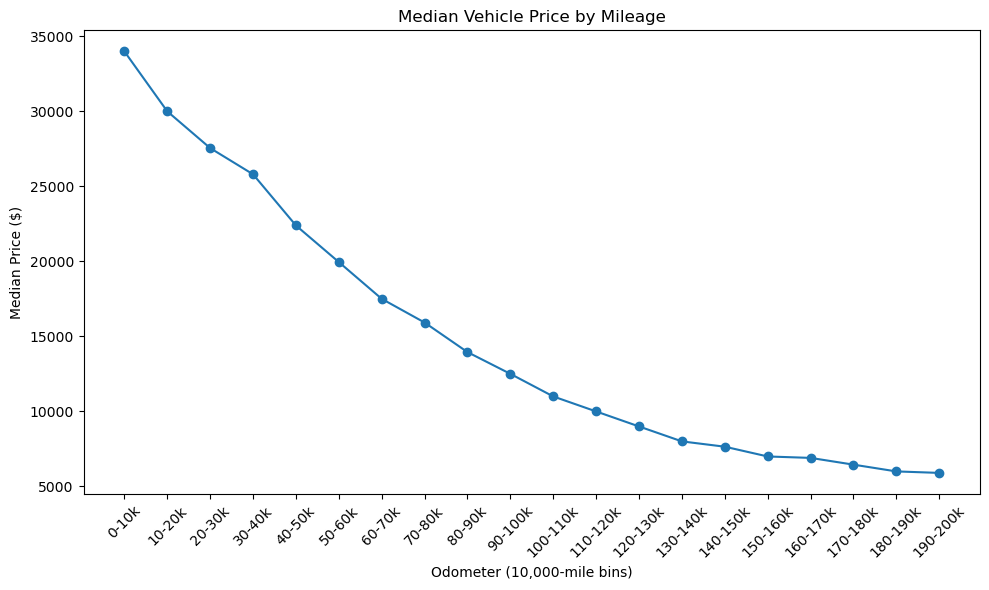

In [142]:
# Median price by odometer bin
odo_price = (
    df.groupby("odometer_bin", observed=True)["price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    odo_price["odometer_bin"].astype(str),
    odo_price["price"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Odometer (10,000-mile bins)")
plt.ylabel("Median Price ($)")
plt.title("Median Vehicle Price by Mileage")

plt.tight_layout()
plt.show()

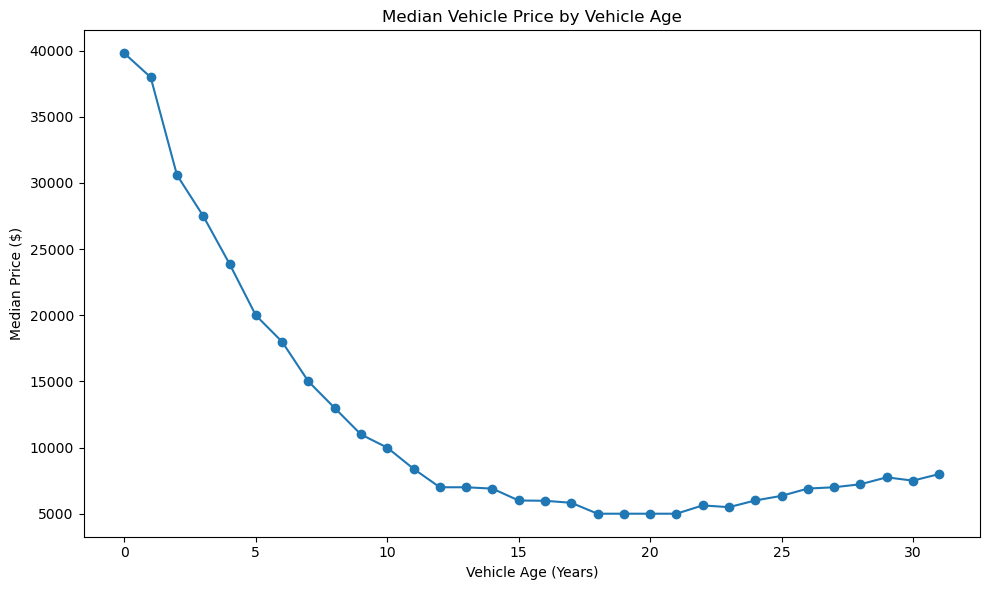

In [143]:
# Median price by vehicle age
age_price = (
    df.groupby("vehicle_age")["price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    age_price["vehicle_age"],
    age_price["price"],
    marker="o"
)

plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Median Price ($)")
plt.title("Median Vehicle Price by Vehicle Age")

plt.tight_layout()
plt.show()

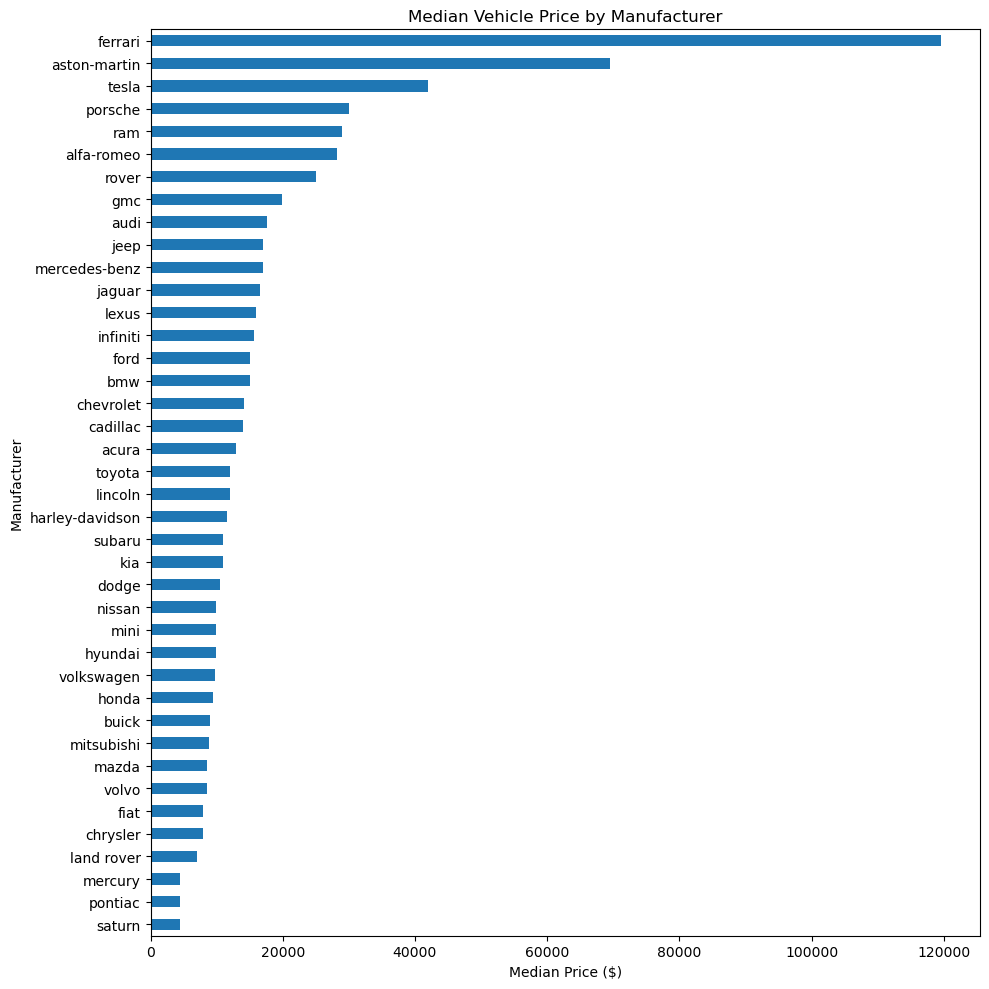

In [144]:
manufacturer_price = (
    df.groupby("manufacturer_imputed")["price"]
      .median()
      .sort_values()
)

plt.figure(figsize=(10, 10))

manufacturer_price.plot(kind="barh")

plt.xlabel("Median Price ($)")
plt.ylabel("Manufacturer")
plt.title("Median Vehicle Price by Manufacturer")

plt.tight_layout()
plt.show()

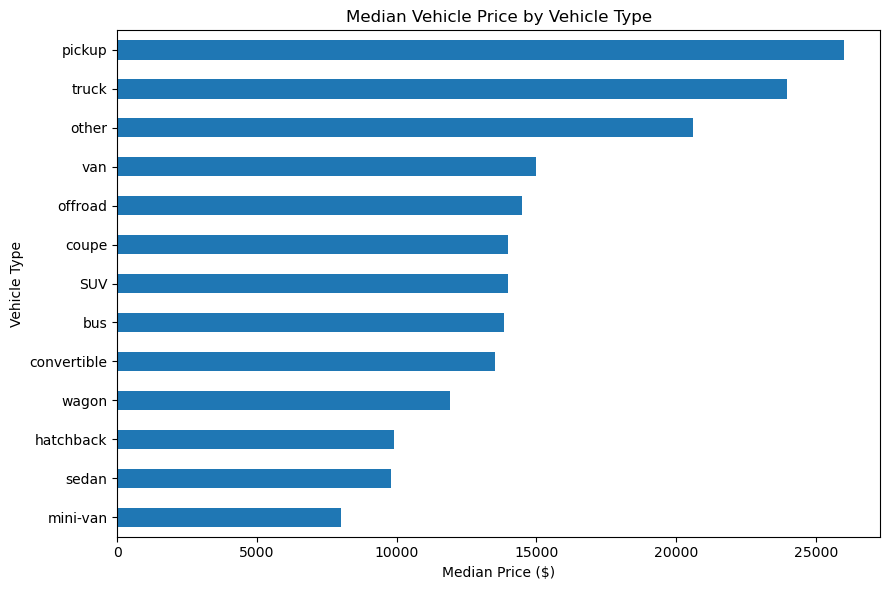

In [145]:
type_price = (
    df.groupby("type")["price"]
      .median()
      .sort_values()
)

plt.figure(figsize=(9, 6))

type_price.plot(kind="barh")

plt.xlabel("Median Price ($)")
plt.ylabel("Vehicle Type")
plt.title("Median Vehicle Price by Vehicle Type")

plt.tight_layout()
plt.show()

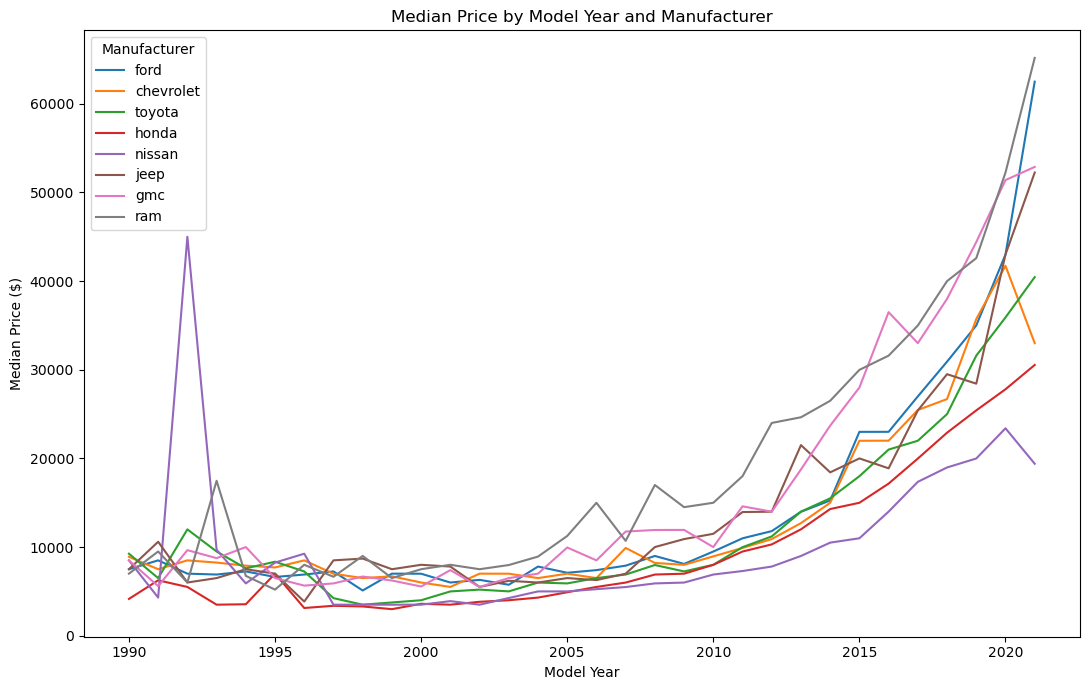

In [146]:
top_manufacturers = (
    df["manufacturer_imputed"]
    .value_counts()
    .head(8)
    .index
)

temp = df[
    df["manufacturer_imputed"].isin(top_manufacturers)
]

manufacturer_year_price = (
    temp.groupby(
        ["year", "manufacturer_imputed"]
    )["price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(11, 7))

for manufacturer in top_manufacturers:
    
    data = manufacturer_year_price[
        manufacturer_year_price["manufacturer_imputed"] == manufacturer
    ]
    
    plt.plot(
        data["year"],
        data["price"],
        label=manufacturer
    )

plt.xlabel("Model Year")
plt.ylabel("Median Price ($)")
plt.title("Median Price by Model Year and Manufacturer")

plt.legend(title="Manufacturer")
plt.tight_layout()
plt.show()

### 4. Modeling

In this section, I run five models:

- Linear regression — Core
- Linear regression — Expanded
- Polynomial regression with age² — Core
- Ridge regression — Core
- Lasso regression — Core

where
- Core specification is  Price = age + odometer bin + manufacturer
- Expanded specification is Price = age + odometer bin + manufacturer + paint color + transmission + fuel + type

For illustration, I also show coefficients from the simples model (core linear regression). I find that holding mileage and manufacturer constant, each additional year of vehicle age is associated with a `$810` lower price, on average. Compared with vehicles with fewer than 10,000 miles (the reference group), vehicles with 100,000–110,000 miles are priced about `$18,370` lower, holding age and manufacturer constant. Manufacturer also matters substantially. For example, compared with Acura (the reference manufacturer), Tesla vehicles are priced about `$19,649` higher. 

In [147]:
# Outcome
y = df["price"]

# Predictor Set 1: Parsimonious
core_features = [
    "vehicle_age",
    "odometer_bin",
    "manufacturer_imputed"
]

# Predictor Set 2: Expanded
expanded_features = [
    "vehicle_age",
    "odometer_bin",
    "manufacturer_imputed",
    "paint_color",
    "transmission",
    "fuel",
    "type"
]

In [148]:
# Keep observations with nonmissing outcome
model_df = df[df["price"].notna()].copy()

train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42
)

y_train = train_df["price"]
y_test = test_df["price"]

print("Training observations:", len(train_df))
print("Test observations:", len(test_df))

Training observations: 158474
Test observations: 39619


In [149]:
#Scaling for Lasso and Ridge 
def make_preprocessor(numeric_features, categorical_features, scale=False):

    if scale:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

### Model 1: Multiple Linear regression (Core)
- Price = age + odometer bin + manufacturer 

In [150]:
core_numeric = [
    "vehicle_age"
]

core_categorical = [
    "odometer_bin",
    "manufacturer_imputed"
]

X_train_core = train_df[core_features]
X_test_core = test_df[core_features]

linear_core = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            core_numeric,
            core_categorical,
            scale=False
        )
    ),
    ("model", LinearRegression())
])

linear_core.fit(
    X_train_core,
    y_train
);

#### Print Coefficients for interpretation

In [151]:
# Get feature names and coefficients from Core Linear Regression
feature_names = (
    linear_core
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    linear_core
    .named_steps["model"]
    .coef_
)

# Create coefficient table
core_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Clean feature names
core_coef_df["feature"] = (
    core_coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("manufacturer_imputed_", "manufacturer: ", regex=False)
    .str.replace("odometer_bin_", "odometer: ", regex=False)
)

# Sort by absolute magnitude
core_coef_df["abs_coefficient"] = (
    core_coef_df["coefficient"].abs()
)

core_coef_df = core_coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

# Format as dollars
core_coef_df["coefficient_dollars"] = (
    core_coef_df["coefficient"]
    .map(lambda x: f"${x:,.0f}")
)

# Display one table
display(
    core_coef_df[
        ["feature", "coefficient_dollars"]
    ].reset_index(drop=True)
)
# Get encoder from the fitted Core Linear Regression
encoder = (
    linear_core
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

print("\nReference groups:")

for variable, categories in zip(
    core_categorical,
    encoder.categories_
):
    print(f"{variable}: {categories[0]}")

,feature,coefficient_dollars
0,manufacturer: ferrari,"$84,873"
1,manufacturer: aston-martin,"$55,627"
2,odometer: 170-180k,"$-20,675"
3,odometer: 190-200k,"$-20,545"
4,odometer: 180-190k,"$-20,321"
5,odometer: 160-170k,"$-20,095"
6,odometer: 140-150k,"$-20,081"
7,odometer: 150-160k,"$-20,043"
8,manufacturer: tesla,"$19,649"
9,odometer: 130-140k,"$-19,495"



Reference groups:
odometer_bin: 0-10k
manufacturer_imputed: acura


### Model 2: Multiple Linear regression (Expanded)  

In [152]:
expanded_numeric = [
    "vehicle_age"
]

expanded_categorical = [
    "odometer_bin",
    "manufacturer_imputed",
    "paint_color",
    "transmission",
    "fuel",
    "type"
]

X_train_expanded = train_df[expanded_features]
X_test_expanded = test_df[expanded_features]

linear_expanded = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            expanded_numeric,
            expanded_categorical,
            scale=False
        )
    ),
    ("model", LinearRegression())
])

linear_expanded.fit(
    X_train_expanded,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['vehicle_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['odometer_bin',
                                                   'manufacturer_imputed',
                                                   'paint_color',
                                                   'transmission', 'fuel',
                                                   'type'])])),
                ('model', LinearRegression())])

### Model 3: Polynomial on age (Core) 
Price = age + age² + mileage category + manufacturer

In [153]:
poly_features = [
    "vehicle_age",
    "age_squared",
    "odometer_bin",
    "manufacturer_imputed"
]

poly_numeric = [
    "vehicle_age",
    "age_squared"
]

poly_categorical = [
    "odometer_bin",
    "manufacturer_imputed"
]

X_train_poly = train_df[poly_features]
X_test_poly = test_df[poly_features]

poly_core = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            poly_numeric,
            poly_categorical,
            scale=False
        )
    ),
    ("model", LinearRegression())
])

poly_core.fit(X_train_poly,y_train);

In [154]:
### Model 4: Ridge Regression (Core) 

In [155]:
ridge_core = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            core_numeric,
            core_categorical,
            scale=True
        )
    ),
    ("model", Ridge())
])

ridge_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

ridge_search = GridSearchCV(
    ridge_core,
    param_grid=ridge_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

ridge_search.fit(X_train_core, y_train);

print("Best Ridge alpha:",
      ridge_search.best_params_["model__alpha"])

print("Best Ridge CV MAE:",
      -ridge_search.best_score_)

ridge_best = ridge_search.best_estimator_

Best Ridge alpha: 1
Best Ridge CV MAE: 6518.1265177294135


### LASSO Regression (Core)

In [156]:
lasso_core = Pipeline([
    (
        "preprocessor",
        make_preprocessor(
            core_numeric,
            core_categorical,
            scale=True
        )
    ),
    (
        "model",
        Lasso(
            max_iter=20000,
            random_state=42
        )
    )
])

In [157]:
lasso_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100,
        500,
        1000
    ]
}

lasso_search = GridSearchCV(
    lasso_core,
    param_grid=lasso_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

lasso_search.fit(X_train_core,y_train);

print("Best Lasso alpha:",
      lasso_search.best_params_["model__alpha"])

print("Best Lasso CV MAE:",
      -lasso_search.best_score_)

lasso_best = lasso_search.best_estimator_

Best Lasso alpha: 1
Best Lasso CV MAE: 6514.899316235457


### 5. Evaluation

When comparing all models, the linear regression with expanded set of variables is the best-performing model, with a test MAE (Mean Absolute Error) of `$5,590`, which means that its predicted vehicle prices differ from observed prices by about `$5,590` on average. This is much better than the core linear model (MAE = `$6,488`), suggesting that color, transmission, fuel, and vehicle type contain meaningful information about used-car prices beyond age, mileage, and manufacturer. The expanded model also has the highest R² (0.63), explaining approximately 63% of the variation in vehicle prices (in the test data). 
(Adding a quadratic age term moderately improves the core model with 3 features (MAE falls from `$6,488` to `$6,287` and R² rises from 0.52 to 0.54), providing some evidence that the relationship between vehicle age and price is nonlinear, as we have seen in the figures).

Ridge and Lasso performed very similarly to the standard linear regression, which is not surprising because I applied them to a simple core model containing only three very important predictors—vehicle age, mileage, and manufacturer. Because the model did not include many unnecessary predictors, there was relatively little for Ridge to shrink or Lasso to eliminate.

Because prediction errors were similar across the training and test data, the models are likely to hold up well on new data. The CV MAE is the average MAE across the 5 cross-validation folds and is very similar to the test MAE across models, suggesting that model performance is stable and not highly dependent on the particular sample of observations. 

Based on this analysis, and linear regression with an expanded set of vehicle information achieved the best performance. A prediction error of approx `$6,000` might still be substantial. For future work, I would expand the regressors to include more variables, such as model. 

In [158]:
def evaluate_model(
    name,
    model,
    X_train,
    X_test
):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Cross-validation
    cv = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=[
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
            "r2"
        ],
        n_jobs=-1
    )

    return {
        "Model": name,

        "Train MAE":
            mean_absolute_error(
                y_train,
                train_pred
            ),

        "CV MAE":
            -cv["test_neg_mean_absolute_error"].mean(),

        "Test MAE":
            mean_absolute_error(
                y_test,
                test_pred
            ),

        "Test RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    test_pred
                )
            ),

        "Test R2":
            r2_score(
                y_test,
                test_pred
            )
    }

In [159]:
results = []

# 1. Linear Core
results.append(
    evaluate_model(
        "Linear - Core",
        linear_core,
        X_train_core,
        X_test_core
    )
)

# 2. Linear Expanded
results.append(
    evaluate_model(
        "Linear - Expanded",
        linear_expanded,
        X_train_expanded,
        X_test_expanded
    )
)

# 3. Polynomial Core
results.append(
    evaluate_model(
        "Polynomial Age² - Core",
        poly_core,
        X_train_poly,
        X_test_poly
    )
)

# 4. Ridge Core
results.append(
    evaluate_model(
        "Ridge - Core",
        ridge_best,
        X_train_core,
        X_test_core
    )
)

# 5. Lasso Core
results.append(
    evaluate_model(
        "Lasso - Core",
        lasso_best,
        X_train_core,
        X_test_core
    )
)

results_df = pd.DataFrame(results)

results_df.round(2)

,Model,Train MAE,CV MAE,Test MAE,Test RMSE,Test R2
0,Linear - Core,"6,514.60","6,518.43","6,488.22","9,877.06",0.52
1,Linear - Expanded,"5,584.96","5,590.12","5,590.33","8,700.95",0.63
2,Polynomial Age² - Core,"6,326.86","6,331.02","6,286.72","9,654.25",0.54
3,Ridge - Core,"6,514.36","6,518.13","6,488.51","9,881.67",0.52
4,Lasso - Core,"6,511.11","6,514.90","6,485.88","9,889.33",0.52


### 6. Deployment

Used-car dealerships could use the best-performing model—the expanded linear regression—as a pricing tool when new vehicles come into their inventory. Dealers could enter a car’s characteristics and use the predicted price as a starting point for setting the listing price. The model could also help flag cars that may be priced too high or too low compared with similar vehicles when negotiating trade-in valuations. However, the model should be used as a decision-support tool rather than an automatic pricing algorithm, since factors not captured in the data, such as local market conditions, inventory stock, and specific vehicle features, may also affect price.

Key findings/recommendations: 
- Newer cars and lower-mileage cards consistently sell for more, and buyers are willing to pay more for certain manufacturers holding other things constant. Use these findings to guide choices in your inventory. 
- A parsimonious model with very few vehicle characteristics was able to predict prices relatively well. For better predictions, getting better information on models, condition, and other car features, might be worth the effort.  